# 🤖 A-Phase · Algorithm Selection, Adapting & Adjusting

Klassische Modelle vergleichen, Features anpassen und Hyperparameter optimieren.

**Projekt:** MietCheck · Big Data & Data Analytics · QUA³CK

In [1]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

COLORS = {"navy": "#14213D", "blue": "#2563EB", "teal": "#0F766E",
          "amber": "#F59E0B", "red": "#DC2626", "grey": "#64748B"}
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"figure.figsize": (9, 4.8), "axes.titleweight": "bold",
                     "axes.labelsize": 10, "figure.dpi": 110})

def load_json(relative_path):
    return json.loads((ROOT / relative_path).read_text(encoding="utf-8"))

print(f"Projektwurzel: {ROOT}")

Projektwurzel: C:\Users\nelek\Desktop\Big Data\MietCheck


## 🤖 A¹: Auswahl geeigneter Algorithmen

Alle Hauptkandidaten erhalten dieselben 600.000 deterministischen Zeilen und dieselben drei `GroupKFold`-Splits über 25-km-Raumblöcke.

| Kandidat | Typ | StandardScaler? | Rolle |
|---|---|---:|---|
| Kategorienmedian | fachliche Baseline | nein | Mindestvergleich |
| Ridge | linear/regularisiert | ja | interpretierbare Baseline |
| LinearSVR | lineare SVM | ja | robuste epsilon-insensitive Regression |
| Decision Tree | einzelner Baum | nein | nichtlineare klassische Referenz |
| Random Forest | Bagging-Ensemble | nein | robuster Challenger |
| HistGradientBoosting | Boosting-Ensemble | nein | skalierbarer Kandidat |
| MLP | neuronales Netz | ja | zusätzlicher nichtlinearer Vergleich |

| Rang | Modell | CV-MAE ± Std. in €/m² |
|---:|---|---:|
| 1 | HistGradientBoosting | **1,305 ± 0,055** |
| 2 | Random Forest | 1,320 ± 0,053 |
| 3 | Decision Tree | 1,393 ± 0,037 |
| 4 | MLP | 1,397 ± 0,076 |
| 5 | Ridge | 1,632 ± 0,105 |
| 6 | LinearSVR | 1,635 ± 0,104 |
| 7 | Kategorienmedian | 1,719 ± 0,125 |

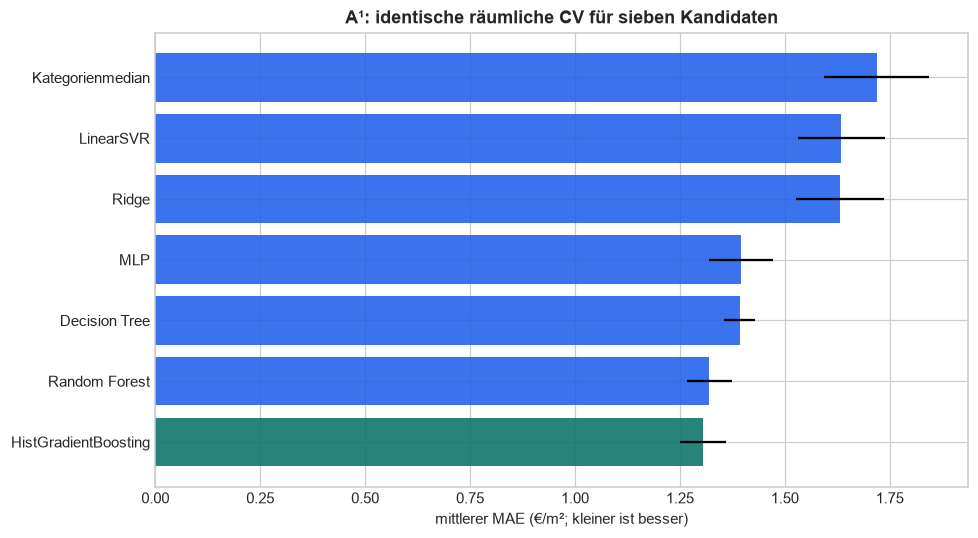

In [2]:
benchmark = load_json("reports/algorithm_benchmark.json")
ranking = pd.DataFrame(benchmark["ranking_by_mean_mae"])
labels = {
    "category_median": "Kategorienmedian", "ridge": "Ridge",
    "linear_svr": "LinearSVR", "decision_tree": "Decision Tree",
    "random_forest": "Random Forest",
    "hist_gradient_boosting": "HistGradientBoosting", "mlp": "MLP",
}
ranking["Modell"] = ranking["model"].map(labels)
plot = ranking.sort_values("mean_mae", ascending=True)
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(plot["Modell"], plot["mean_mae"], xerr=plot["std_mae"],
        color=[COLORS["teal"] if name == "HistGradientBoosting" else COLORS["blue"]
               for name in plot["Modell"]], alpha=.9)
ax.set(title="A¹: identische räumliche CV für sieben Kandidaten",
       xlabel="mittlerer MAE (€/m²; kleiner ist besser)", ylabel="")
plt.tight_layout(); plt.show()

### Ergänzung: lineare und Kernel-SVM

Ein exakter RBF-SVR skaliert superlinear und ist für 600.000 Zeilen kein glaubwürdiger Produktionskandidat. Deshalb vergleicht ein ergänzender Machbarkeitstest LinearSVR und RBF-SVR auf 10.000 deterministischen Zeilen mit identischer räumlicher 3-Fold-Logik. Beide Pipelines enthalten den `StandardScaler` innerhalb des Folds.

| SVM-Variante | Zeilen | MAE in €/m² | Training je Fold |
|---|---:|---:|---:|
| LinearSVR | 10.000 | 1,620 | 0,017 s |
| RBF-SVR | 10.000 | **1,518** | 2,315 s |

Der Kernel verbessert den kleinen Machbarkeitstest, benötigt aber bereits rund das 137-Fache der Trainingszeit. Wegen des superlinearen Wachstums ist RBF-SVR kein glaubwürdiger Kandidat für den 600.000-Zeilen-Hauptvergleich.

**A¹-Entscheidung:** HistGradientBoosting gewinnt den fairen Hauptvergleich (MAE ≈ 1,305 €/m²), knapp vor Random Forest. Es ist zugleich kompakter und schneller bei der Inferenz. SVM und Einzelbaum erfüllen den klassischen Methodenvergleich, erreichen aber nicht die beste räumliche Generalisierung.

## 🧩 A²: Feature Engineering und inkrementelle Anpassung

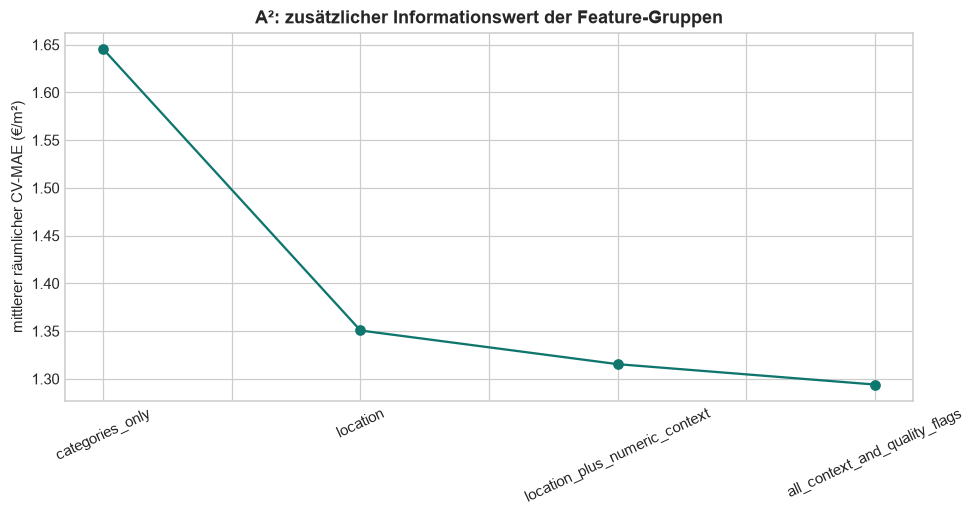

In [3]:
ablation = load_json("reports/feature_ablation.json")
ablation_rows = []
for name, details in ablation["feature_sets"].items():
    ablation_rows.append({
        "Feature-Set": name,
        "Anzahl Merkmale": len(details["features"]),
        "MAE": details["summary"]["mean_mae"],
        "R²": details["summary"]["mean_r2"],
    })
ablation_df = pd.DataFrame(ablation_rows)

ax = ablation_df.plot(
    x="Feature-Set",
    y="MAE",
    marker="o",
    color=COLORS["teal"],
    legend=False,
)
ax.set(title="A²: zusätzlicher Informationswert der Feature-Gruppen",
       ylabel="mittlerer räumlicher CV-MAE (€/m²)", xlabel="")
ax.tick_params(axis="x", rotation=25)
plt.tight_layout(); plt.show()

Die vier Stufen sind: Kategorien → + Lagekoordinaten → + Wohnumfeld → + amtliche Unsicherheitsindikatoren. Die Lage liefert den größten Zusatznutzen. Unsicherheitsindikatoren bleiben trotz kleinerem inkrementellem Effekt erhalten, weil sie die Datenqualität fachlich abbilden.

## ⚙️ A³: Automatisierte Hyperparameteroptimierung

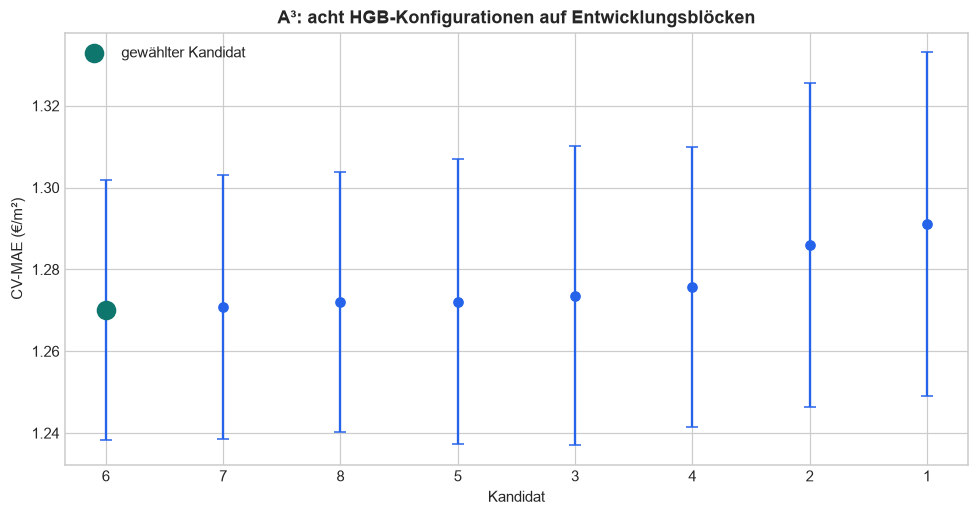

In [4]:
tuning = load_json("reports/hgb_tuning.json")
tuning_df = pd.DataFrame([
    {
        "Kandidat": item["candidate"],
        "MAE": item["summary"]["mean_mae"],
        "Std.": item["summary"]["std_mae"],
        "Worst Fold": item["summary"]["worst_fold_mae"],
        "R²": item["summary"]["mean_r2"],
    }
    for item in tuning["candidates"]
]).sort_values("MAE")
fig, ax = plt.subplots(figsize=(9, 4.8))
ax.errorbar(tuning_df["Kandidat"].astype(str), tuning_df["MAE"],
            yerr=tuning_df["Std."], fmt="o", color=COLORS["blue"], capsize=4)
selected = str(tuning["selected_candidate"])
row = tuning_df[tuning_df["Kandidat"].astype(str) == selected].iloc[0]
ax.scatter([selected], [row["MAE"]], s=140, color=COLORS["teal"], zorder=3,
           label="gewählter Kandidat")
ax.set(title="A³: acht HGB-Konfigurationen auf Entwicklungsblöcken",
       xlabel="Kandidat", ylabel="CV-MAE (€/m²)")
ax.legend(); plt.tight_layout(); plt.show()

Das theory-guided Grid variiert Lernrate, Iterationen, Blattzahl, Mindestblattgröße und L2-Regularisierung. Kalibrierungs- und Testblöcke bleiben während A¹–A³ gesperrt. Die Auswahl berücksichtigt mittleren MAE, Streuung und schlechtesten Fold – nicht nur einen Einzelwert.

## ✅ Ergebnis der A-Phase

- **Champion:** `HistGradientBoostingRegressor`
- **Challenger:** Random Forest
- **Scaler:** in Ridge-, LinearSVR-, RBF-SVR- und MLP-Pipelines fold-intern; nicht beim baumbasierten Champion
- **Features:** Lage + Kategorien + Wohnumfeld + Unsicherheitsindikatoren
- **Tuning:** acht reproduzierbare Kandidaten ausschließlich auf Entwicklungsblöcken
- **Übergabe an C:** Parameter und Split-Hashes werden versioniert eingefroren

---

**Reproduzierbarkeit:** Kennzahlen stammen aus versionierten JSON-/CSV-Artefakten. Die genannten Skripte erzeugen sie aus den öffentlichen Rohdaten erneut. Schwere Trainingsläufe liegen bewusst in getesteten Skripten, damit Notebook und produktive Pipeline dieselben Splits, Parameter und Reports verwenden.